In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

csv_path = "/content/drive/MyDrive/Colab/fertilizer_recommendation_enhanced.csv"

df = pd.read_csv(csv_path)

print(df.shape)
df.head()

(10000, 30)


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Temperature,Humidity,...,Soil_Health_Score,Disease_Risk,Water_Availability,Weather_Condition,Farmer_Experience,Land_Size,Market_Demand,Expected_Yield,NPK_Ratio,Fertilizer_Cost
0,Clay,6.07,34.98,0.32,1.87,61,44,84,19.84,83.31,...,63.00,Medium,High,Rainy,15,5.20,Low,1.44,61:44:84,950.0
1,Silt,6.39,47.34,0.28,0.21,59,56,18,24.40,46.27,...,44.33,Low,High,Cloudy,14,14.89,Medium,4.61,59:56:18,350.0
2,Sandy,7.92,38.13,0.99,1.88,43,21,119,24.82,71.86,...,61.00,Medium,High,Cloudy,19,12.48,High,7.97,43:21:119,350.0
3,Clay,5.86,14.17,1.46,0.36,88,46,34,27.87,53.23,...,56.00,Low,High,Sunny,25,18.58,Low,1.99,88:46:34,950.0
4,Clay,7.98,19.28,0.85,2.16,104,53,98,24.17,51.87,...,85.00,Low,High,Sunny,13,9.39,Low,7.96,104:53:98,700.0


In [4]:
print(df.columns.tolist())

['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Temperature', 'Humidity', 'Rainfall', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Previous_Crop', 'Region', 'Fertilizer_Used_Last_Season', 'Yield_Last_Season', 'Recommended_Fertilizer', 'Soil_Health_Score', 'Disease_Risk', 'Water_Availability', 'Weather_Condition', 'Farmer_Experience', 'Land_Size', 'Market_Demand', 'Expected_Yield', 'NPK_Ratio', 'Fertilizer_Cost']


In [5]:
X = df.drop("Recommended_Fertilizer", axis=1)
y = df["Recommended_Fertilizer"]

In [6]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    penalty='l2',
    C=1.0,
    max_iter=5000,
    random_state=42
)

log_reg.fit(X_train, y_train)

print("Regularized Logistic Regression Trained Successfully")

Regularized Logistic Regression Trained Successfully


In [10]:
from sklearn.metrics import accuracy_score

y_pred_lr = log_reg.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.96


In [11]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       199
           1       1.00      1.00      1.00       584
           2       0.96      0.99      0.98       282
           3       0.86      0.80      0.83       128
           4       0.43      0.27      0.33        37
           5       1.00      1.00      1.00       620
           6       0.84      0.91      0.88       150

    accuracy                           0.96      2000
   macro avg       0.86      0.85      0.85      2000
weighted avg       0.96      0.96      0.96      2000



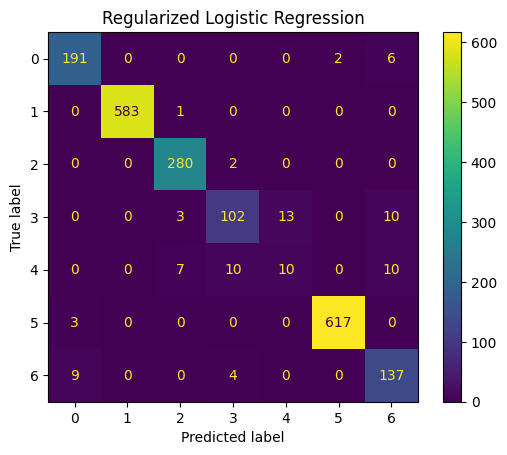

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Regularized Logistic Regression")
plt.show()

In [13]:
import joblib

joblib.dump(log_reg, "logistic_regression_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [14]:
from google.colab import files

files.download("logistic_regression_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Regularized Logistic Regression"],
    "Accuracy": [lr_accuracy]
})

print(results)

                             Model  Accuracy
0  Regularized Logistic Regression      0.96
